# Classifying weather images - XAI

This project consists in predicting the type of weather shown in images.

This notebook provides an **eXplainable AI (XAI)** extension to the project notebook to explain the neural networks decisions. 

<img src="data/dataset/snow/0840.jpg" width="500">

## Imports

On HubroHub, you need to install the required XAI libraries. Many libraries exist but we use Captum in this example.

In [1]:
!pip install captum --quiet

In [2]:
# We rely on several libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [3]:
# Magic formulae so that changes in the .py files are loaded in here
%load_ext autoreload
%autoreload 2
###

    
# We load in some code we've defined elsewhere, in the src folder
from src.weather_helpers import (
    WeatherDataset, filepath, metapath, reset_seeds, plot_learning_curves, get_class_name
)

from src.define_model import Net

from src.train_and_evaluate import evaluate_model, evaluate_wrapper, train_model

## Data handling

This data set is bigger than the ones in the lecture exercises: we have several thousand images, and we don't want to show them all to the model at the same time. Therefore, we use the below data set and data loader wrappers to our data.

In [4]:
# We have some objects that hold our data.
# The data split has already been done for us
# (if you're curious, you can look in src/preprocess_data.py)
start = time.time()
D = 64 # data dimensionality
trainset = WeatherDataset(filepath, metapath, subset='train', D=D)
valset = WeatherDataset(filepath, metapath, subset='val', D=D)
print(f'Data loading took {np.round(time.time()-start, 4)} seconds.')

Data loading took 26.6473 seconds.


In [5]:
B = 64 # batch_size
# Pytorch provides data loaders, which helpfully groups our data into batches
# Here we also choose to shuffle the training data, but not the validation data
train_dataloader = DataLoader(trainset, batch_size=B, shuffle=True)
val_dataloader = DataLoader(valset, batch_size=B, shuffle=False)

In [6]:
# Debugging: Make sure we have a GPU available 
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )
print(f'Using device: {device}')

Using device: mps


### Example images, as represented by the model
Below we show how the images are provided to the model. We have reduced the image resolution to reduce the data size. 

How much detail these images have is controlled by the hyperparameter **D** that's passed to `WeatherDataset`. You can play with this! What happens if we set `D=64`? Does the training time change? Does the accuracy change?

Text(0.5, 1.0, 'Image Class: dew')

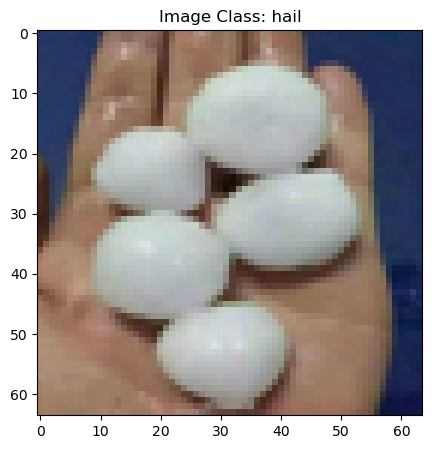

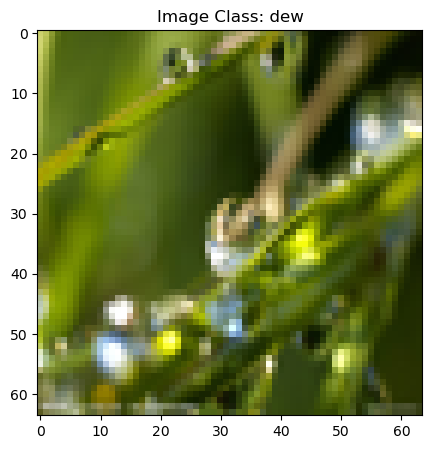

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(np.array(trainset._loaded_images[10].T, dtype=int))
ax.set_title(f'Image Class: {get_class_name(trainset._labels[10])}')

fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(np.array(trainset._loaded_images[500].T, dtype=int))
ax.set_title(f'Image Class: {get_class_name(trainset._labels[500])}')


## Baseline

In [8]:
# Let's come up with a baseline:
# What accuracy would we get by randomly guessing the class for each image?
reset_seeds(1) # Make things reproducible
random_preds = np.random.randint(0, 11, len(valset))
# Make an array with all the validation true labels
val_labels = np.hstack([ll.numpy() for _, ll in val_dataloader])

# Compare the true and random labels
rand_acc = 100*np.sum(random_preds == val_labels)/len(val_labels)
print(f'Random accuracy: {rand_acc:.4f}%')

Random accuracy: 9.4382%


## Let's train the model!

When we train the model we will evaluate it before training and after each epoch on the full training and validation sets. 

In [ ]:
epochs =  10 # epoch: number of times we should the model the full data set

In [ ]:
reset_seeds(1) # Make things reproducible
net = Net(D=D) # Set up our model
net.to(device) # Send it to the gpu
# Let's choose some hyperparameters:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=0.0001, weight_decay=1e-4)

# Train our model
train_curve, val_curve = train_model(
    net, val_dataloader, train_dataloader, device, epochs, optimizer, criterion)


Accuracy of the network on the val images: 7.7154 %
Accuracy of the network on the train images: 6.6202 %
Epoch: 	0
[1,     1] loss: 0.002
[1,    11] loss: 0.015
[1,    21] loss: 0.013
[1,    31] loss: 0.012
[1,    41] loss: 0.011
[1,    51] loss: 0.011
[1,    61] loss: 0.011
Accuracy of the network on the val images: 35.7303 %
Accuracy of the network on the train images: 35.7889 %
Epoch: 	1
[2,     1] loss: 0.001
[2,    11] loss: 0.010
[2,    21] loss: 0.010
[2,    31] loss: 0.010
[2,    41] loss: 0.010
[2,    51] loss: 0.009
[2,    61] loss: 0.009
Accuracy of the network on the val images: 42.9963 %
Accuracy of the network on the train images: 43.0314 %
Epoch: 	2
[3,     1] loss: 0.001
[3,    11] loss: 0.009
[3,    21] loss: 0.009
[3,    31] loss: 0.008
[3,    41] loss: 0.008
[3,    51] loss: 0.008
[3,    61] loss: 0.008
Accuracy of the network on the val images: 46.2172 %
Accuracy of the network on the train images: 47.6108 %
Epoch: 	3
[4,     1] loss: 0.001
[4,    11] loss: 0.008
[

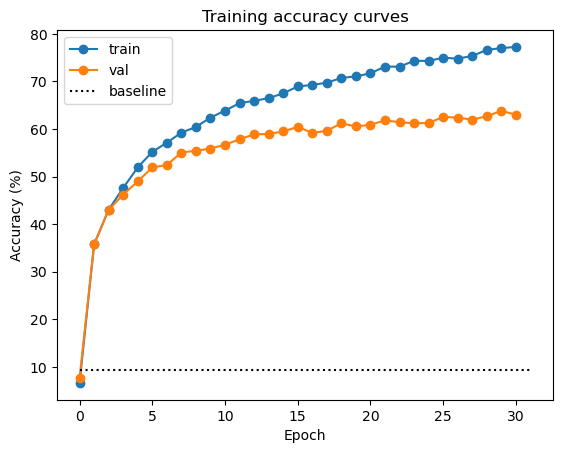

In [17]:
plot_learning_curves(train_curve, val_curve, baseline=rand_acc, title='Training accuracy curves')

## **XAI part**
### Now you're ready to explain the model predictions

We start by making all of the predictions of the validation dataset. We also determine all correct predictions and create a dictionnary called `indices_correct_predictions`.

In [18]:
X_val = torch.stack([valset[k][0] for k in range (len(valset))])
y_val = np.stack([valset[k][1] for k in range (len(valset))])
# Logits are the raw outputs of the model
predictions_logits = net(X_val.to(device))
# The softmax function turns logits into probabilities, by exponentiating them and normalizing
predicted_probabilities = torch.softmax(predictions_logits, dim=1).detach()
# The predicted class is the one with the highest probability
predicted_classes = predicted_probabilities.max(axis=1).indices.cpu().numpy()
# Computes a dictionary where the keys are the class labels (0-10) and the values are the indices of the correctly predicted samples for each class
indices_correct_predictions = {k: np.where((predicted_classes == y_val) & (y_val == k))[0] for k in range(11)}

### **Single sample attribution**

We start by explaining one specific prediction.

> #### **QUESTION 1**
> 1. Import `IntegratedGradients` from `captum.attr`
> 2. Define the attribution method by instanciating `IntegratedGradients` with our neural network, and call this new object `ig`.
>
>--- 


In [19]:
from captum.attr import IntegratedGradients
ig = IntegratedGradients(net)

> #### **QUESTION 2**
> - Explain one correct prediction using integrated gradients from `Captum`. You can use the dictionnary `indices_correct_predictions` create above which contains all indices of correct prediction for each of the weather types.
>
> - Call the resulting object **`attributions`**.
>
>
> Here are the different classes. You can choose the one you prefer.
>
> | 0   | 1       | 2     | 3     | 4    | 5         | 6    | 7       | 8    | 9          | 10   |
> |-----|---------|-------|-------|------|-----------|------|---------|------|------------|------|
> | dew | fogsmog | frost | glaze | hail | lightning | rain | rainbow | rime | sandstorm | snow |
>
> ---
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Choose a sample ID in the `indices_correct_predictions` dictionnary.
> - Create an input tensor `X_sample`, corresponding to the sample ID and extracted from `X_val`.
> - Since the model expects shape *(n_samples, channels, X, Y)*, use `X_val[[sample_id]]` with two bracket pairs.
> - Put the tensor on the correct device with `.to(device)`.
> - Determine the target you want to explain (i.e. the class number).
> - use the `ig` method defined above to compute explaination with `ig.attribute`
> </details>


In [20]:
# Choose sample id to explain
sample_id = indices_correct_predictions[5][5]
print(f'Sample id: {sample_id}')

target_of_explanation = int(predicted_classes[sample_id])
print(f'Target class for explanation: {get_class_name(target_of_explanation)}')

#Extract the sample we want to explain, and make sure it has gradients enabled
X_sample = X_val[[sample_id]].to(device)
X_sample = X_sample.requires_grad_() # This is not required here as X_val has already been set to require gradients, but it's good practice to make sure the input has gradients enabled before passing it to the explainer.

# Explain predictions using Integrated Gradients
attributions = ig.attribute(X_sample, target=target_of_explanation)

print(f"Attributions shape: {attributions.shape}")

Sample id: 1268
Target class for explanation: lightning
Attributions shape: torch.Size([1, 3, 64, 64])


#### Plot the resulting attributions

The attribution shape is the same as the input image: for each input pixel, we get an information of how important it is. 

> #### **QUESTION 3**
> Our attribution is now a 4 dimensional *(n_samples, channels, X, Y)* tensor on the gpu.
> 
> - Transform this into a numpy array and sum across the channels to make it 2D. 
> - You can call this array `attributions_numpy_2d`.
> 
> We will then plot the attributions next to the original image to figure out what input pixels were important for the model decision.
> 
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Put the tensor to the cpu with `.to('cpu')`.
> - Detach the gradients with `.detach()`.
> - Convert the tensor to numpy with `.numpy()`.
> - Extract the 3D array from the 4D array by getting the first element or squeezing the array: `array[0]` or `.squeeze()`.
> - Sum over the first axis of the array with `.sum(axis=0)`.
> </details>

Attributions shape (2D): (64, 64)


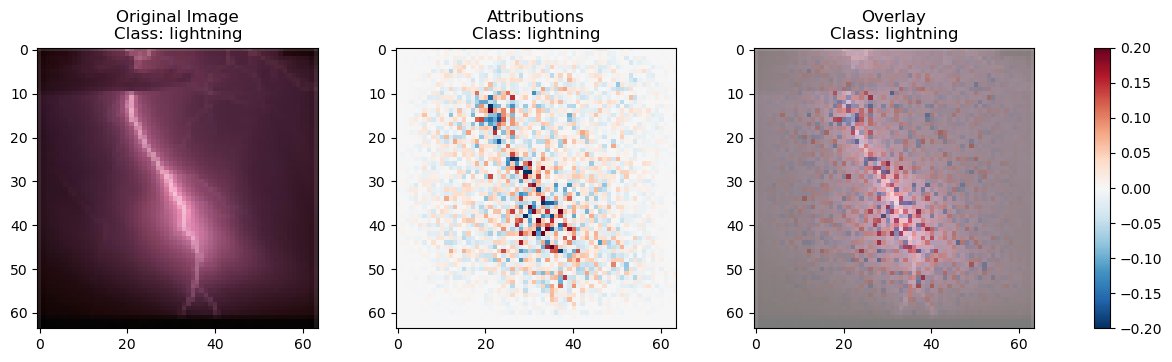

In [21]:
attributions_numpy = attributions.cpu().detach().numpy()
attributions_numpy_2d = attributions_numpy[0].sum(axis=0)
print(f"Attributions shape (2D): {attributions_numpy_2d.shape}")

fig, axs = plt.subplots(1, 4, figsize=(12,3.6),width_ratios=[1,1,1,0.05])
axs[0].imshow(np.array(valset._loaded_images[sample_id].T, dtype=int))
axs[0].set_title(f'Original Image\nClass: {get_class_name(y_val[sample_id])}')
im = axs[1].imshow(attributions_numpy_2d.T, cmap='RdBu_r', vmax=.2, vmin=-.2)
axs[1].set_title(f'Attributions\nClass: {get_class_name(target_of_explanation)}')

axs[2].imshow(np.array(valset._loaded_images[sample_id].T, dtype=int))
axs[2].imshow(attributions_numpy_2d.T, cmap='RdBu_r', vmax=.2, vmin=-.2, alpha=.5)
axs[2].set_title(f'Overlay\nClass: {get_class_name(target_of_explanation)}')
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04, cax=axs[3])
plt.tight_layout()
plt.show()

### **Multi sample attributions**

Now let's try to figure out why the model succeeds in general for one class. 

> #### **QUESTION 4**
> - Use integrated gradients to explain all correct predictions of dew (class `0`). 
> - Call the resulting object `attributions_correct_dew`.
>
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Get all correct dew predictions indices from the `indices_correct_predictions` dictionnary.
> - Create an input tensor `X_dew_correct`, corresponding to the sample IDs and extracted from `X_val`.
> - Put the tensor on the correct device with `.to(device)`.
> - Determine the target you want to explain (i.e. the class number of dew).
> - use the `ig` method defined above to compute explanation with `ig.attribute`
> </details>



<div class="alert alert-block alert-warning">
    <b>Warning:</b> If you try to explain too many samples at once, integrated gradients may crash the notebook.
</div>


In [22]:
#Extract the sample we want to explain, and make sure it has gradients enabled
indices_correct_predictions_dew = indices_correct_predictions[0]
X_dew_correct = X_val[indices_correct_predictions[0]].to(device)
X_dew_correct = X_dew_correct.requires_grad_() # This is not required here as X_val has already been set to require gradients, but it's good practice to make sure the input has gradients enabled before passing it to the explainer.

print(f"Number of correctly predicted dew samples: {X_dew_correct.shape[0]}")

# Choose explanation target
target_of_explanation = 0
print(f'Target class for explanation: {get_class_name(target_of_explanation)}')

# Explain predictions using Integrated Gradients
attributions_dew_correct = ig.attribute(X_dew_correct, target=target_of_explanation)

print(f"Attributions shape: {attributions_dew_correct.shape}")

Number of correctly predicted dew samples: 116
Target class for explanation: dew
Attributions shape: torch.Size([116, 3, 64, 64])


#### Plot the resulting attributions


> #### **QUESTION 5**
> As before, our attribution is a 4 dimensional *(n_sample, channels, X, Y)* tensor on the gpu. 
> But now instead of summing across the channels, we will average across the samples and plot all three channels (i.e. colors) separately. 
>
> In the input data and attributions, the order of pixel colors is **Red**, **Green** and **Blue**.
> 
> - Transform this into a numpy array and average across the samples to make it 3d. 
> - You can call this array `attributions_dew_correct_numpy_sample_mean`.
> 
> We will then plot the average attributions for the three colors separately.
> 
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Put the tensor to the cpu with `.to('cpu')`.
> - Detach the gradients with `.detach()`.
> - Convert the tensor to numpy with `.numpy()`.
> - Average across the first axis of the array with `.mean(axis=0)`.
> </details>

Attributions shape (3D): (3, 64, 64)


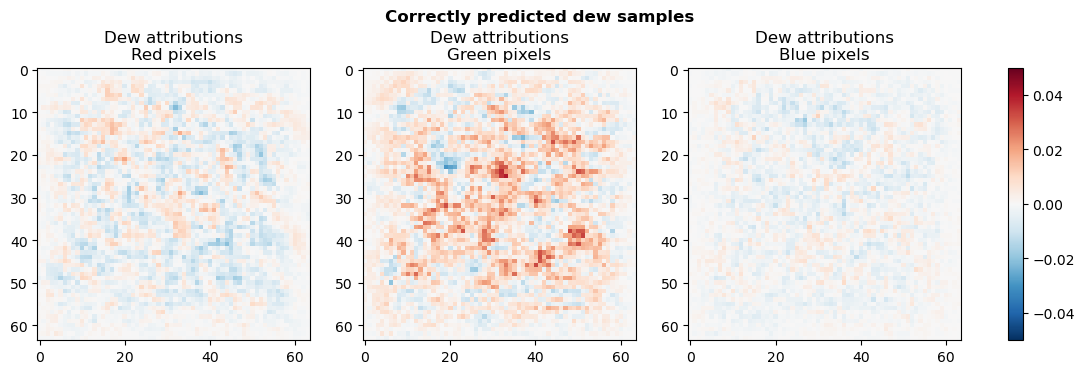

In [37]:
attributions_dew_correct_numpy = attributions_dew_correct.cpu().detach().numpy()
attributions_dew_correct_numpy_sample_mean = attributions_dew_correct_numpy.mean(axis=0)
print(f"Attributions shape (3D): {attributions_dew_correct_numpy_sample_mean.shape}")

fig, axs = plt.subplots(1, 4, figsize=(11,3.6),width_ratios=[1,1,1,0.05])
im = axs[0].imshow(attributions_dew_correct_numpy_sample_mean[0].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[1].imshow(attributions_dew_correct_numpy_sample_mean[1].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[2].imshow(attributions_dew_correct_numpy_sample_mean[2].T, cmap='RdBu_r', vmax=.05, vmin=-.05)

axs[0].set_title(f'Dew attributions\nRed pixels')
axs[1].set_title(f'Dew attributions\nGreen pixels')
axs[2].set_title(f'Dew attributions\nBlue pixels')

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04, cax=axs[3])
plt.suptitle('Correctly predicted dew samples', weight='bold')
plt.tight_layout()
plt.show()

We see a very strong signal that the model is relying on one color. Let's figure out if this is because of very strong samples, or if this is a general model strategy.

> #### **QUESTION 6**
> This tim, we will sum attribution across X and Y to determine the contribution of each color to the prediction. 
> In the input data and attributions, the order of pixel colors is **Red**, **Green** and **Blue**.
> 
> - Transform `attributions_dew_correct` into a numpy array (or reuse the one from the exercice above) and sum across the last two axis to make it 2D with the shape *(n_samples, channels)*. 
> - You can call this array `attributions_dew_correct_numpy_per_color_sum`.
> 
> We will then plot these values to figure out if one color is systematically the most important. 
> 
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Put the tensor to the cpu with `.to('cpu')`.
> - Detach the gradients with `.detach()`.
> - Convert the tensor to numpy with `.numpy()`.
> - Sum over the last two axis of the array with `.sum(axis=-1).sum(axis=-1)`.
> </details>

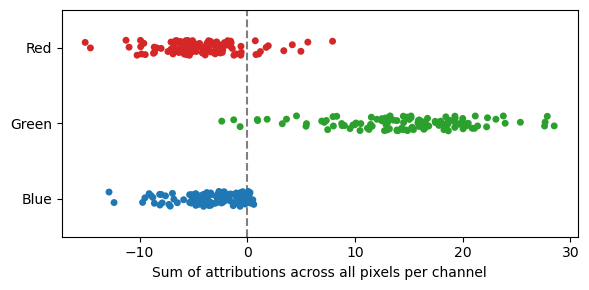

In [ ]:
attributions_dew_correct_numpy = attributions_dew_correct.cpu().detach().numpy()
attributions_dew_correct_numpy_per_color_sum = attributions_dew_correct_numpy.sum(axis=-1).sum(axis=-1)

fig, ax = plt.subplots(figsize=(6,3))
sns.stripplot(attributions_dew_correct_numpy_per_color_sum, 
              palette=['C3','C2','C0'], orient='h',
              ax=ax)
ax.set_xlabel('Sum of attributions across all pixels per channel')
ax.set_yticks([0,1,2])
ax.set_yticklabels(['Red', 'Green', 'Blue'])
ax.axvline(0, color='grey', linestyle='--')
ax.set_title('Correctly predicted dew samples')
plt.tight_layout()
plt.show()

> #### **BONUS QUESTIONS**
> 1. Follow the same procedure for the false predictions, i.e. the target was **not** dew, but the model predicted dew anyway.
> 2. Follow the same procedure for another class (i.e. hail, lightning, ...).
>
>---

#### **Same with incorrect predictions**


In [29]:
#Extract the sample we want to explain, and make sure it has gradients enabled
indices_false_predictions_dew = np.where((predicted_classes == 0) & (y_val != 0))[0]
X_dew_false = X_val[indices_false_predictions_dew].to(device)
X_dew_false = X_dew_false.requires_grad_() # This is not required here as X_val has already been set to require gradients, but it's good practice to make sure the input has gradients enabled before passing it to the explainer.

print(f"Number of falsely predicted dew samples: {X_dew_false.shape[0]}")

# Choose explanation target
target_of_explanation = 0
print(f'Target class for explanation: {get_class_name(target_of_explanation)}')

# Explain predictions using Integrated Gradients
attributions_dew_false = ig.attribute(X_dew_false, target=target_of_explanation)

print(f"Attributions shape: {attributions_dew_false.shape}")


Number of falsely predicted dew samples: 36
Target class for explanation: dew
Attributions shape: torch.Size([36, 3, 64, 64])


Attributions shape (3D): (3, 64, 64)


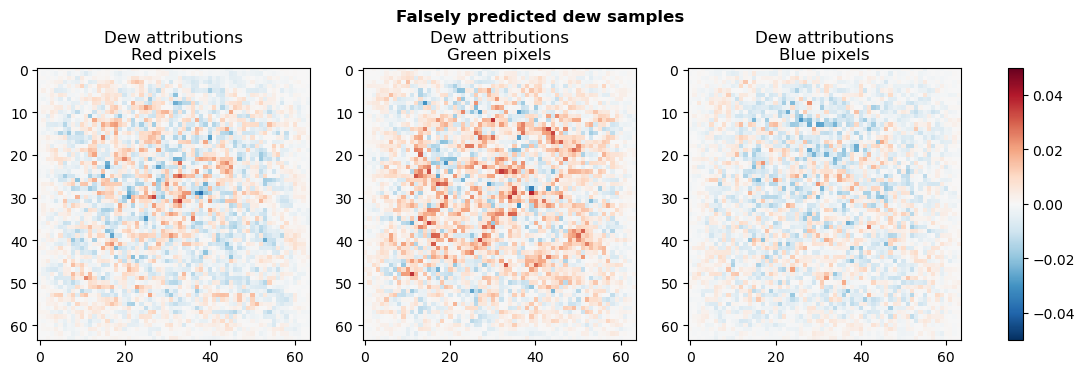

In [38]:
attributions_dew_false_numpy = attributions_dew_false.cpu().detach().numpy()
attributions_dew_false_numpy_sample_mean = attributions_dew_false_numpy.mean(axis=0)
print(f"Attributions shape (3D): {attributions_dew_false_numpy_sample_mean.shape}")

fig, axs = plt.subplots(1, 4, figsize=(11,3.6),width_ratios=[1,1,1,0.05])
im = axs[0].imshow(attributions_dew_false_numpy_sample_mean[0].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[1].imshow(attributions_dew_false_numpy_sample_mean[1].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[2].imshow(attributions_dew_false_numpy_sample_mean[2].T, cmap='RdBu_r', vmax=.05, vmin=-.05)

axs[0].set_title(f'Dew attributions\nRed pixels')
axs[1].set_title(f'Dew attributions\nGreen pixels')
axs[2].set_title(f'Dew attributions\nBlue pixels')

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04, cax=axs[3])
plt.suptitle('Falsely predicted dew samples', weight='bold')
plt.tight_layout()
plt.show()

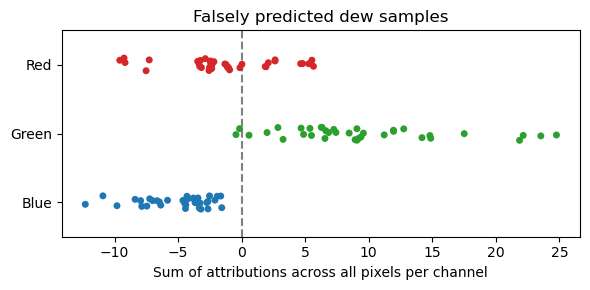

In [32]:
attributions_dew_false_numpy = attributions_dew_false.cpu().detach().numpy()
attributions_dew_false_numpy_per_color_sum = attributions_dew_false_numpy.sum(axis=-1).sum(axis=-1)

fig, ax = plt.subplots(figsize=(6,3))
sns.stripplot(attributions_dew_false_numpy_per_color_sum, 
              palette=['C3','C2','C0'], orient='h',
              ax=ax)
ax.set_xlabel('Sum of attributions across all pixels per channel')
ax.set_yticks([0,1,2])
ax.set_yticklabels(['Red', 'Green', 'Blue'])
ax.axvline(0, color='grey', linestyle='--')
ax.set_title('Falsely predicted dew samples')
plt.tight_layout()
plt.show()

#### **Same with sandstorm**

In [ ]:
#Extract the sample we want to explain, and make sure it has gradients enabled
indices_correct_predictions_sandstorm = indices_correct_predictions[9]
X_sandstorm_correct = X_val[indices_correct_predictions_sandstorm].to(device)
X_sandstorm_correct = X_sandstorm_correct.requires_grad_() # This is not required here as X_val has already been set to require gradients, but it's good practice to make sure the input has gradients enabled before passing it to the explainer.

print(f"Number of correctly predicted sandstorm samples: {X_sandstorm_correct.shape[0]}")

# Choose explanation target
target_of_explanation = 9
print(f'Target class for explanation: {get_class_name(target_of_explanation)}')

# Explain predictions using Integrated Gradients
attributions_sandstorm_correct = ig.attribute(X_sandstorm_correct, target=target_of_explanation)

print(f"Attributions shape: {attributions_sandstorm_correct.shape}")


Number of correctly predicted sandstorm samples: 98
Target class for explanation: sandstorm
Attributions shape: torch.Size([98, 3, 64, 64])


Attributions shape (3D): (3, 64, 64)


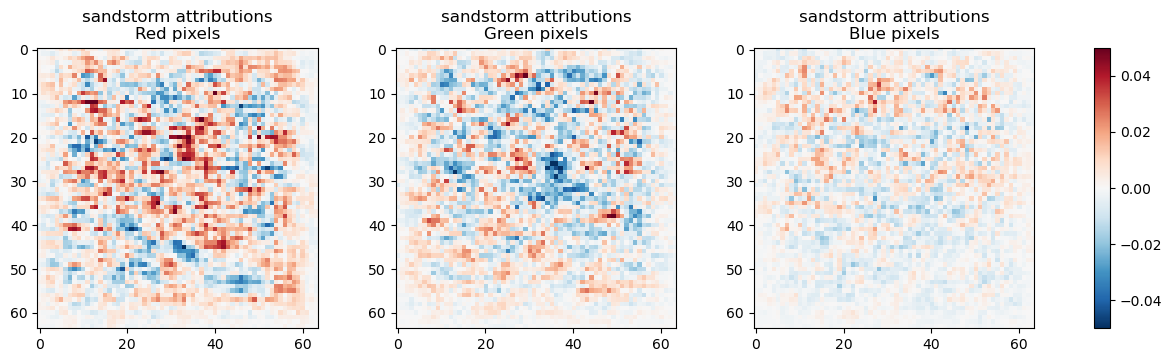

In [ ]:
attributions_sandstorm_correct_numpy = attributions_sandstorm_correct.cpu().detach().numpy()
attributions_numpy_sample_mean = attributions_sandstorm_correct_numpy.mean(axis=0)
print(f"Attributions shape (3D): {attributions_numpy_sample_mean.shape}")

fig, axs = plt.subplots(1, 4, figsize=(12,3.6),width_ratios=[1,1,1,0.05])
im = axs[0].imshow(attributions_numpy_sample_mean[0].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[1].imshow(attributions_numpy_sample_mean[1].T, cmap='RdBu_r', vmax=.05, vmin=-.05)
axs[2].imshow(attributions_numpy_sample_mean[2].T, cmap='RdBu_r', vmax=.05, vmin=-.05)

axs[0].set_title(f'sandstorm attributions\nRed pixels')
axs[1].set_title(f'sandstorm attributions\nGreen pixels')
axs[2].set_title(f'sandstorm attributions\nBlue pixels')

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04, cax=axs[3])
plt.tight_layout()
plt.show()

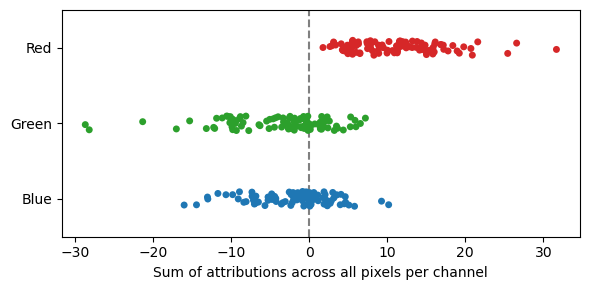

In [ ]:
attributions_sandstorm_correct_numpy = attributions_sandstorm_correct.cpu().detach().numpy()
attributions_sandstorm_correct_numpy_per_color_sum = attributions_sandstorm_correct_numpy.sum(axis=-1).sum(axis=-1)

fig, ax = plt.subplots(figsize=(6,3))
sns.stripplot(attributions_sandstorm_correct_numpy_per_color_sum, 
              palette=['C3','C2','C0'], orient='h',
              ax=ax)
ax.set_xlabel('Sum of attributions across all pixels per channel')
ax.set_yticks([0,1,2])
ax.set_yticklabels(['Red', 'Green', 'Blue'])
ax.axvline(0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

# THE END